# Part 1 — Data Acquisition, Cleaning, and Exploratory Analysis

Run each cell from top to bottom (or click **Run All** in the toolbar / Kernel menu).
This notebook is self-contained: the first cell generates the raw dataset, then every
task from the brief runs in order. Plots display inline below each cell **and** are saved
into the `plots/` folder next to this notebook.

## Setup — imports

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 20)
sns.set_theme(style='whitegrid')
os.makedirs('data', exist_ok=True)
os.makedirs('plots', exist_ok=True)
print('Setup complete.')

Setup complete.


## Step 0 — Generate the raw dataset

This project environment has no external dataset download available, so a realistic
synthetic "Employee Compensation & Performance" dataset is generated here with
documented relationships and deliberately-injected data-quality issues (nulls,
duplicates, a messy dtype column, skew, outliers) — see the markdown notes for what
each issue is and why it's there. `random_state=42` throughout, so this is fully
reproducible.

In [4]:
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
N = 2000

education_levels = ['High School', 'Bachelors', 'Masters', 'PhD']
education_probs = [0.25, 0.40, 0.25, 0.10]
education_level = rng.choice(education_levels, size=N, p=education_probs)

departments = ['Sales', 'Engineering', 'Marketing', 'HR', 'Finance', 'Support']
department_probs = [0.22, 0.28, 0.14, 0.10, 0.14, 0.12]
department = rng.choice(departments, size=N, p=department_probs)

regions = ['North', 'South', 'East', 'West', 'Central']
region = rng.choice(regions, size=N)

age = rng.integers(22, 61, size=N).astype(float)
career_start_age = rng.normal(23, 2.5, size=N)
years_experience = np.clip(age - career_start_age + rng.normal(0, 1.5, size=N), 0, 40)

performance_score = np.clip(rng.normal(3.2, 0.7, size=N), 1, 5)
monthly_hours = rng.gamma(shape=6.0, scale=25.0, size=N)
distance_from_office_km = rng.exponential(scale=8.0, size=N)
num_projects = rng.poisson(4, size=N).clip(0, 15)
bonus_pct = np.clip(rng.normal(10 + performance_score * 2, 4, size=N), 0, 30)

education_bump = {'High School': 0, 'Bachelors': 8000, 'Masters': 15000, 'PhD': 25000}
department_bump = {'Sales': 0, 'Engineering': 12000, 'Marketing': 3000,
                    'HR': -2000, 'Finance': 9000, 'Support': -4000}

salary = (30000
          + years_experience * 1800
          + np.array([education_bump[e] for e in education_level])
          + np.array([department_bump[d] for d in department])
          + performance_score * 3000
          + rng.normal(0, 4000, size=N))
salary = np.round(salary, 2)

years_experience_str = np.round(years_experience, 1).astype(str)
# ~1.5% of entries recorded as 'unknown' instead of a number (messy client export)
na_idx = rng.choice(N, size=int(N * 0.015), replace=False)
years_experience_str[na_idx] = 'unknown'

df = pd.DataFrame({
    'employee_id': np.arange(1, N + 1),
    'age': age,
    'years_experience': years_experience_str,
    'education_level': education_level,
    'department': department,
    'region': region,
    'performance_score': np.round(performance_score, 2),
    'monthly_hours': np.round(monthly_hours, 1),
    'distance_from_office_km': np.round(distance_from_office_km, 2),
    'num_projects': num_projects,
    'bonus_pct': np.round(bonus_pct, 2),
    'salary': salary,
})

def inject_nulls(frame, col, frac):
    idx = rng.choice(frame.index, size=int(len(frame) * frac), replace=False)
    frame.loc[idx, col] = np.nan

inject_nulls(df, 'performance_score', 0.07)
inject_nulls(df, 'monthly_hours', 0.05)
inject_nulls(df, 'distance_from_office_km', 0.06)
inject_nulls(df, 'bonus_pct', 0.35)  # deliberately exceeds the 20% threshold

dupes = df.sample(n=15, random_state=RANDOM_STATE)
df = pd.concat([df, dupes], ignore_index=True)
df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

df.to_csv('data/raw_data.csv', index=False)
print(f'raw_data.csv written: {df.shape[0]} rows, {df.shape[1]} columns')

raw_data.csv written: 2015 rows, 12 columns


## Task 1 — Load and inspect

In [5]:
df = pd.read_csv('data/raw_data.csv')
print(df.head())
print()
print(df.dtypes)
print()
print('Shape:', df.shape)

   employee_id   age years_experience education_level   department region  performance_score  monthly_hours  \
0         1199  41.0             16.7       Bachelors        Sales  North               2.45          123.0   
1          527  56.0             35.0             PhD      Support   East                NaN          181.2   
2          394  39.0             13.9         Masters        Sales  North               3.47           86.9   
3         1408  51.0             26.8     High School  Engineering  South               3.75           98.5   
4          434  36.0             16.4         Masters  Engineering   West               3.61          209.7   

   distance_from_office_km  num_projects  bonus_pct     salary  
0                    19.22             1      16.05   68904.53  
1                    21.45             4      16.62  122813.41  
2                     6.81             5      15.33   78883.95  
3                     3.49             2        NaN   98529.81  
4       

## Task 2 — Null value analysis

In [6]:
null_counts = df.isnull().sum()
null_pct = (df.isnull().sum() / df.shape[0]) * 100
null_table = pd.DataFrame({'null_count': null_counts, 'null_pct': null_pct.round(2)})
print(null_table)

exceed_20 = null_table[null_table['null_pct'] > 20]
print()
print('Columns exceeding 20% null rate:')
print(exceed_20)

                         null_count  null_pct
employee_id                       0      0.00
age                               0      0.00
years_experience                  0      0.00
education_level                   0      0.00
department                        0      0.00
region                            0      0.00
performance_score               140      6.95
monthly_hours                   101      5.01
distance_from_office_km         123      6.10
num_projects                      0      0.00
bonus_pct                       705     34.99
salary                            0      0.00

Columns exceeding 20% null rate:
           null_count  null_pct
bonus_pct         705     34.99


**Decision:** `bonus_pct` exceeds 20% missing (~35%). At that level, imputing a single
value would be standing in for roughly a third of the column, risking a false signal in
any later model — so it is **dropped** rather than filled. All other numeric columns are
below 20% and are filled with the **median** (not the mean), because the mean gets pulled
toward whichever tail has more extreme values (see Task 5's skewness discussion) while
the median stays representative of a typical row.

In [7]:
cols_to_drop = list(exceed_20.index)
if cols_to_drop:
    print(f'Dropping columns exceeding 20% nulls: {cols_to_drop}')
    df = df.drop(columns=cols_to_drop)

numeric_cols_with_nulls = [c for c in df.columns
                            if df[c].isnull().sum() > 0 and pd.api.types.is_numeric_dtype(df[c])]
print(f'Numeric columns to median-fill: {numeric_cols_with_nulls}')
for col in numeric_cols_with_nulls:
    df[col] = df[col].fillna(df[col].median())

print()
print('Nulls remaining after fill:')
print(df.isnull().sum())

Dropping columns exceeding 20% nulls: ['bonus_pct']
Numeric columns to median-fill: ['performance_score', 'monthly_hours', 'distance_from_office_km']

Nulls remaining after fill:
employee_id                0
age                        0
years_experience           0
education_level            0
department                 0
region                     0
performance_score          0
monthly_hours              0
distance_from_office_km    0
num_projects               0
salary                     0
dtype: int64


## Task 3 — Duplicate detection and removal

In [8]:
n_dupes = df.duplicated().sum()
print(f'Duplicate rows found: {n_dupes}')

null_pct_before = (df.isnull().sum() / df.shape[0]) * 100
df = df.drop_duplicates()
null_pct_after = (df.isnull().sum() / df.shape[0]) * 100

print(f'Rows removed: {n_dupes}. New shape: {df.shape}')
print()
print('Null % before vs after duplicate removal:')
print(pd.DataFrame({'before': null_pct_before.round(3), 'after': null_pct_after.round(3)}))

Duplicate rows found: 15
Rows removed: 15. New shape: (2000, 11)

Null % before vs after duplicate removal:
                         before  after
employee_id                 0.0    0.0
age                         0.0    0.0
years_experience            0.0    0.0
education_level             0.0    0.0
department                  0.0    0.0
region                      0.0    0.0
performance_score           0.0    0.0
monthly_hours               0.0    0.0
distance_from_office_km     0.0    0.0
num_projects                0.0    0.0
salary                      0.0    0.0


## Task 4 — Data type correction

In [9]:
mem_before = df.memory_usage(deep=True).sum()
print(f'Memory usage before conversion: {mem_before} bytes ({mem_before/1024:.1f} KB)')

print(f"years_experience dtype before conversion: {df['years_experience'].dtype}")
df['years_experience'] = pd.to_numeric(df['years_experience'], errors='coerce')
new_nulls = df['years_experience'].isnull().sum()
print(f'New NaNs introduced by coercion (e.g. "unknown" placeholders): {new_nulls}')
df['years_experience'] = df['years_experience'].fillna(df['years_experience'].median())
print(f"years_experience dtype after conversion:  {df['years_experience'].dtype}")

df['department'] = df['department'].astype('category')
df['education_level'] = df['education_level'].astype('category')
df['region'] = df['region'].astype('category')

mem_after = df.memory_usage(deep=True).sum()
print(f'Memory usage after conversion:  {mem_after} bytes ({mem_after/1024:.1f} KB)')
print(f'Memory reduction: {mem_before - mem_after} bytes ({(1 - mem_after/mem_before)*100:.1f}% smaller)')
print()
print(df.dtypes)

Memory usage before conversion: 569148 bytes (555.8 KB)
years_experience dtype before conversion: object
New NaNs introduced by coercion (e.g. "unknown" placeholders): 30
years_experience dtype after conversion:  float64
Memory usage after conversion:  151347 bytes (147.8 KB)
Memory reduction: 417801 bytes (73.4% smaller)

employee_id                   int64
age                         float64
years_experience            float64
education_level            category
department                 category
region                     category
performance_score           float64
monthly_hours               float64
distance_from_office_km     float64
num_projects                  int64
salary                      float64
dtype: object


## Task 5 — Descriptive statistics and skewness

In [10]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'employee_id']
print(df[numeric_cols].describe())

skew_vals = df[numeric_cols].skew().sort_values(key=lambda s: s.abs(), ascending=False)
print()
print('Skewness (sorted by absolute value):')
print(skew_vals)
most_skewed_col = skew_vals.index[0]
print(f'\nMost skewed column: {most_skewed_col} (skew = {skew_vals.iloc[0]:.3f})')

               age  years_experience  performance_score  monthly_hours  distance_from_office_km  num_projects  \
count  2000.000000       2000.000000        2000.000000     2000.00000              2000.000000   2000.000000   
mean     41.113500         18.258800           3.185080      148.16780                 7.725680      4.019500   
std      11.149788         11.225513           0.674799       59.27162                 7.428355      2.052127   
min      22.000000          0.000000           1.020000       28.80000                 0.000000      0.000000   
25%      32.000000          8.700000           2.760000      106.50000                 2.547500      3.000000   
50%      41.500000         18.400000           3.170000      139.55000                 5.610000      4.000000   
75%      51.000000         27.325000           3.610000      178.02500                10.152500      5.000000   
max      60.000000         40.000000           5.000000      417.90000                57.570000 

**Interpretation:** the most skewed column is positively (right) skewed — a long tail of
large values pulls the mean above the median, so mean-imputation would overstate a
'typical' value for this column. This is why median (not mean) was used for imputation
in Task 2/8a.

## Task 6 — Outlier detection (IQR method)

In [11]:
iqr_cols = ['distance_from_office_km', 'monthly_hours']
for col in iqr_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f'{col}: Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}, '
          f'bounds=({lower:.2f}, {upper:.2f}), outliers={n_outliers} '
          f'({n_outliers/len(df)*100:.1f}% of rows)')

distance_from_office_km: Q1=2.55, Q3=10.15, IQR=7.61, bounds=(-8.86, 21.56), outliers=125 (6.2% of rows)
monthly_hours: Q1=106.50, Q3=178.03, IQR=71.53, bounds=(-0.79, 285.31), outliers=57 (2.9% of rows)


**Decision:** outliers are **retained, not dropped** — they represent plausible real
values (long commutes, heavy-overtime months), not data-entry errors. In Part 2,
`StandardScaler` reduces their disproportionate influence on linear/logistic models;
tree-based models in Part 3 are largely insensitive to this kind of outlier by
construction, so no additional capping is planned.

## Task 7 — Visualizations

### 7.1 Line plot — salary by row index

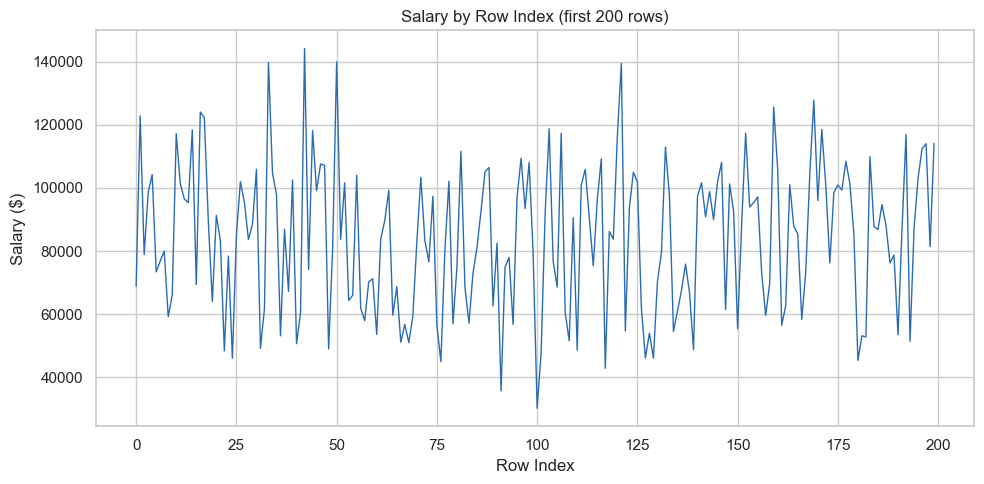

In [12]:
plt.figure(figsize=(10, 5))
plt.plot(df.index[:200], df['salary'].values[:200], color='#2b6cb0', linewidth=1)
plt.title('Salary by Row Index (first 200 rows)')
plt.xlabel('Row Index')
plt.ylabel('Salary ($)')
plt.tight_layout()
plt.savefig('plots/01_line_salary.png', dpi=120)
plt.show()

### 7.2 Bar chart — mean salary by department

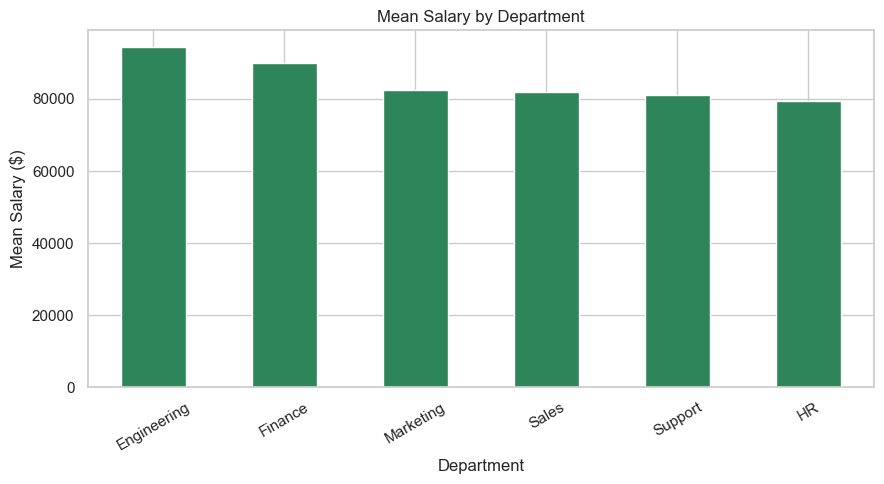

department
Engineering    94316.830783
Finance        90043.271919
Marketing      82535.600780
Sales          81897.153554
Support        80999.088936
HR             79316.948477
Name: salary, dtype: float64


In [13]:
plt.figure(figsize=(9, 5))
dept_means = df.groupby('department', observed=True)['salary'].mean().sort_values(ascending=False)
dept_means.plot.bar(color='#2f855a')
plt.title('Mean Salary by Department')
plt.xlabel('Department')
plt.ylabel('Mean Salary ($)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('plots/02_bar_mean_salary_by_department.png', dpi=120)
plt.show()
print(dept_means)

### 7.3 Histogram — most skewed column

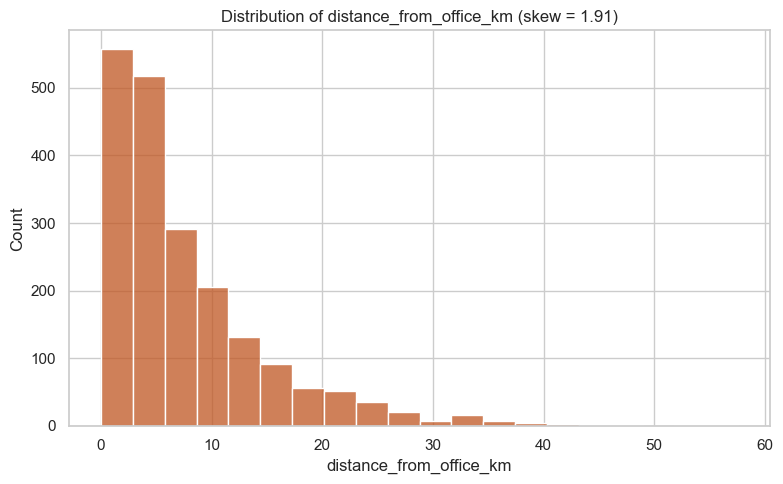

In [14]:
plt.figure(figsize=(8, 5))
sns.histplot(df[most_skewed_col], bins=20, color='#c05621')
plt.title(f'Distribution of {most_skewed_col} (skew = {skew_vals.iloc[0]:.2f})')
plt.xlabel(most_skewed_col)
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('plots/03_histogram_most_skewed.png', dpi=120)
plt.show()

### 7.4 Scatter plot — years_experience vs salary

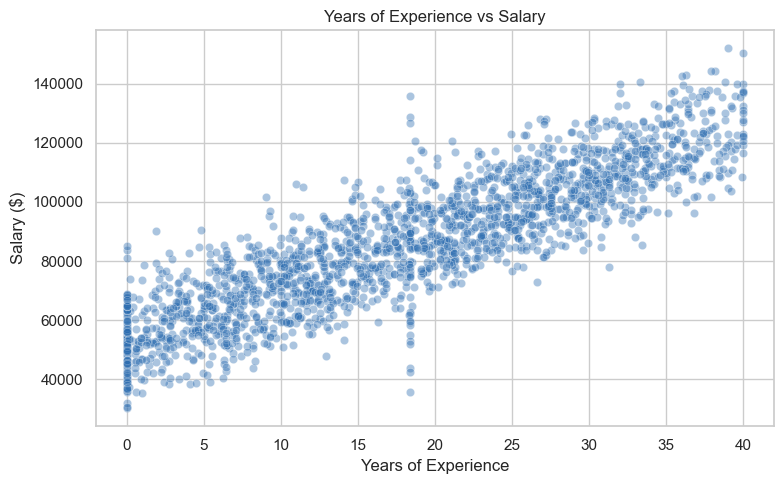

Pearson correlation: 0.8781073614809186


In [15]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='years_experience', y='salary', alpha=0.4, color='#2b6cb0')
plt.title('Years of Experience vs Salary')
plt.xlabel('Years of Experience')
plt.ylabel('Salary ($)')
plt.tight_layout()
plt.savefig('plots/04_scatter_experience_salary.png', dpi=120)
plt.show()
print('Pearson correlation:', df['years_experience'].corr(df['salary']))

### 7.5 Box plot — salary by education level

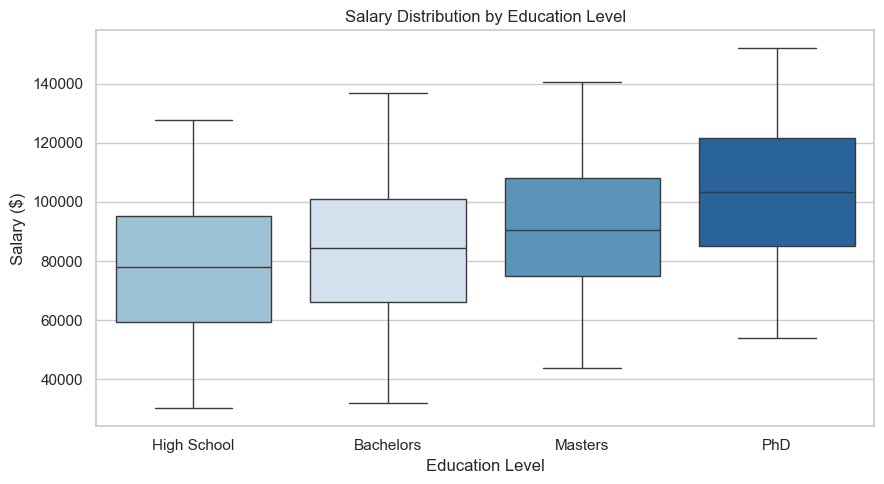

education_level
High School     77983.230
Bachelors       84320.515
Masters         90482.900
PhD            103438.520
Name: salary, dtype: float64


In [16]:
plt.figure(figsize=(9, 5))
order = ['High School', 'Bachelors', 'Masters', 'PhD']
sns.boxplot(data=df, x='education_level', y='salary', order=order,
            hue='education_level', palette='Blues', legend=False)
plt.title('Salary Distribution by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Salary ($)')
plt.tight_layout()
plt.savefig('plots/05_box_salary_by_education.png', dpi=120)
plt.show()
print(df.groupby('education_level', observed=True)['salary'].median().reindex(order))

### 7.6 Correlation heat map

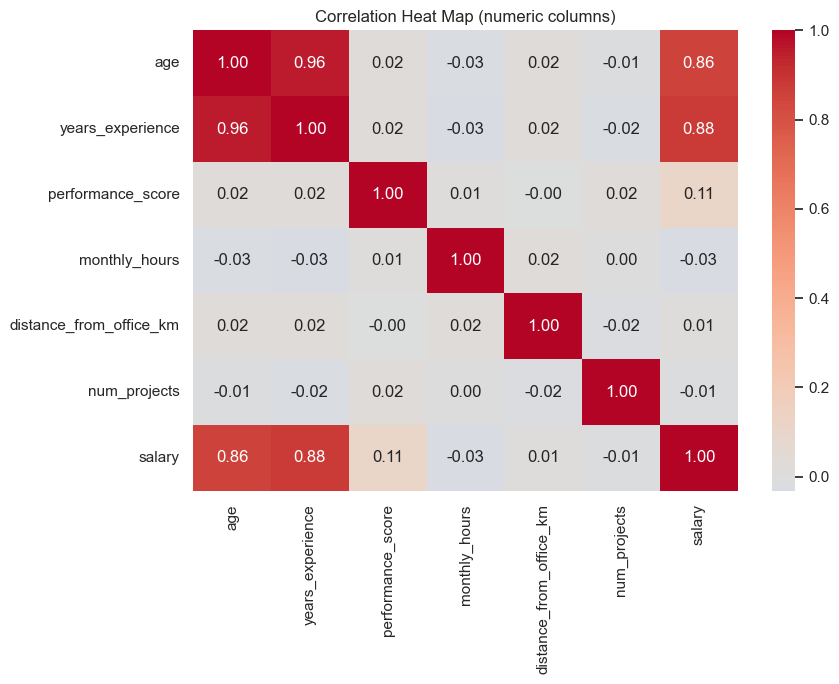

Highest |correlation| pair: ('age', 'years_experience') = 0.959


In [17]:
plt.figure(figsize=(9, 7))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heat Map (numeric columns)')
plt.tight_layout()
plt.savefig('plots/06_correlation_heatmap.png', dpi=120)
plt.show()

corr_unstacked = corr_matrix.where(~np.eye(len(corr_matrix), dtype=bool)).unstack().dropna()
top_pair = corr_unstacked.abs().idxmax()
print(f'Highest |correlation| pair: {top_pair} = {corr_unstacked[top_pair]:.3f}')

**Interpretation:** the highest correlation pair is `age` and `years_experience` — this
is not a simple causal relationship; both are driven by a shared underlying factor
(career-start age plus elapsed time), which is a plausible alternative explanation for
the correlation rather than one variable causing the other.

## Task 8a — Imputation strategy comparison (mean vs median)

In [18]:
top2_skew_cols = skew_vals.index[:2].tolist()
for col in top2_skew_cols:
    print(f'{col}: mean = {df[col].mean():.3f}, median = {df[col].median():.3f}, '
          f'skew = {skew_vals[col]:.3f}, remaining nulls = {df[col].isnull().sum()}')

distance_from_office_km: mean = 7.726, median = 5.610, skew = 1.913, remaining nulls = 0
monthly_hours: mean = 148.168, median = 139.550, skew = 0.922, remaining nulls = 0


## Task 8b — Spearman vs Pearson correlation

In [19]:
pearson_matrix = df[numeric_cols].corr(method='pearson')
spearman_matrix = df[numeric_cols].corr(method='spearman')

diff_matrix = (spearman_matrix - pearson_matrix).abs()
diff_unstacked = diff_matrix.where(~np.eye(len(diff_matrix), dtype=bool)).unstack().dropna()
seen = set(); rows = []
for (a, b), val in diff_unstacked.sort_values(ascending=False).items():
    key = frozenset([a, b])
    if key in seen:
        continue
    seen.add(key)
    rows.append((a, b, pearson_matrix.loc[a, b], spearman_matrix.loc[a, b], val))
    if len(rows) == 3:
        break

diff_table = pd.DataFrame(rows, columns=['col_a', 'col_b', 'pearson', 'spearman', 'abs_diff'])
print(diff_table)

               col_a                    col_b   pearson  spearman  abs_diff
0      monthly_hours  distance_from_office_km  0.017466  0.044980  0.027515
1  performance_score  distance_from_office_km -0.001712 -0.028508  0.026797
2       num_projects  distance_from_office_km -0.018146 -0.005047  0.013098


## Task 8c — Grouped aggregation

In [20]:
grouped = df.groupby('department', observed=True)['salary'].agg(['mean', 'std', 'count'])
print(grouped)
print()
print('Highest mean group:', grouped['mean'].idxmax())
print('Highest std group:', grouped['std'].idxmax())
print('Ratio of highest to lowest group mean:', grouped['mean'].max() / grouped['mean'].min())

                     mean           std  count
department                                    
Engineering  94316.830783  21714.606171    562
Finance      90043.271919  23875.524478    271
HR           79316.948477  22155.881466    197
Marketing    82535.600780  21311.137963    282
Sales        81897.153554  22646.306126    453
Support      80999.088936  23482.612728    235

Highest mean group: Engineering
Highest std group: Finance
Ratio of highest to lowest group mean: 1.1891132046019222


## Save cleaned dataset

In [21]:
df.to_csv('cleaned_data.csv', index=False)
print(f'cleaned_data.csv saved. Final shape: {df.shape}')

cleaned_data.csv saved. Final shape: (2000, 11)
